# The count behind 40 percent

**Week 1, Thursday. Chapter 3 of 6.** By the end of this notebook you can count what a rate stands
on, run a chance reference for a small count, choose between trusting, testing and waiting, and
reach the same share a second way, then check the idea itself on orders that did not rise.

> **The client asks.** "Student is up 40 percent; should I move budget there?"
>
> Meera Raghavan, CEO, Kalpa Retail

**The metric at stake.** Orders per quarter in the Student segment, Q2 against Q1. **Who asks and
what rides on it.** Meera, deciding whether acquisition money follows the fastest-growing segment:
move it on a rate that chance made and the budget is spent on a segment that may be flat next
quarter. **Who else faces it.** In the 1990s the Gates Foundation put money behind small schools,
partly because small schools were over-represented among the best performers. The statistician
Howard Wainer showed they were over-represented among the worst as well, which is what small
counts do: by 2001 the Foundation had given about 1.7 billion dollars to education projects, and
Wainer's essay calls that a costly lesson in how far small groups swing.

Chapters 1 and 2 found the Retail-Plus fall borderline and small against the company. Meera's
second question is about a rise, the biggest on the page. This chapter adds `orders_in` and
`flip_rises`, a chance reference built for a count.

**Setup.** The toolkit so far, plus the two new helpers.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import itertools
import random
import statistics

ORDERS = kit.load_csv("C2_W01_D04_orders_STUDENT.csv")
SEGMENTS = ["Retail-Core", "Retail-Plus", "Student", "Business"]


def mean(values):
    return sum(values) / len(values)


def member_totals(segment, quarter):
    """Delivered revenue per member of one segment in one quarter, members always in the same order."""
    members = sorted({o["customer_id"] for o in ORDERS if o["segment"] == segment})
    totals = {m: 0 for m in members}
    for o in ORDERS:
        if o["segment"] == segment and o["quarter"] == quarter and o["status"] == "delivered":
            totals[o["customer_id"]] += int(o["amount"])
    return [totals[m] for m in members]


def flip_gaps(q1, q2, times, seed):
    """The same members measured twice: a coin per member decides which of its two quarters is Q1."""
    random.seed(seed)                              # the same coins on every laptop
    diffs = [a - b for a, b in zip(q1, q2)]        # each member's own Q1 less Q2
    gaps = []
    for _ in range(times):
        flipped = [d if random.random() < 0.5 else -d for d in diffs]   # heads keeps, tails swaps
        gaps.append(mean(flipped))
    return gaps


def shuffle_gaps(q1, q2, times, seed):
    """Two groups of different customers: deal every value to two piles at random, many times."""
    random.seed(seed)
    pool = q1 + q2                                 # all the values, labels ignored
    gaps = []
    for _ in range(times):
        random.shuffle(pool)                       # deal at random
        gaps.append(mean(pool[:len(q1)]) - mean(pool[len(q1):]))
    return gaps


def share_at_least(gaps, real):
    """Counting one direction: the share of chance-only worlds with a gap at least as large as the real one."""
    return sum(1 for g in gaps if g >= real) / len(gaps)


def share_either(gaps, real):
    """Counting either direction: the share of chance-only worlds with a gap that large, up or down."""
    return sum(1 for g in gaps if abs(g) >= abs(real)) / len(gaps)


def delivered(segment, quarter):
    """A segment's delivered revenue in one quarter, in rupees."""
    return sum(int(o["amount"]) for o in ORDERS
               if o["segment"] == segment and o["quarter"] == quarter and o["status"] == "delivered")


def bootstrap_gaps(q1, q2, times, seed):
    """The same members twice: redraw the members' own Q1 less Q2 differences with replacement."""
    random.seed(seed)
    diffs = [a - b for a, b in zip(q1, q2)]
    return [mean([random.choice(diffs) for _ in diffs]) for _ in range(times)]


def orders_in(segment, quarter):
    return sum(1 for o in ORDERS if o["segment"] == segment and o["quarter"] == quarter)


def flip_rises(n_orders, times, seed):
    """Deal each of n orders to Q1 or Q2 by a fair coin, many times, and keep each rise."""
    random.seed(seed)
    rises = []
    for _ in range(times):
        q2 = sum(1 for _ in range(n_orders) if random.random() < 0.5)
        q1 = n_orders - q2
        rises.append(float("inf") if q1 == 0 else q2 / q1 - 1)
    return rises

print("toolkit ready:", ", ".join(["member_totals", "flip_gaps", "shuffle_gaps", "share_at_least",
                                   "share_either", "delivered", "bootstrap_gaps", "orders_in", "flip_rises"]))

toolkit ready: member_totals, flip_gaps, shuffle_gaps, share_at_least, share_either, delivered, bootstrap_gaps, orders_in, flip_rises


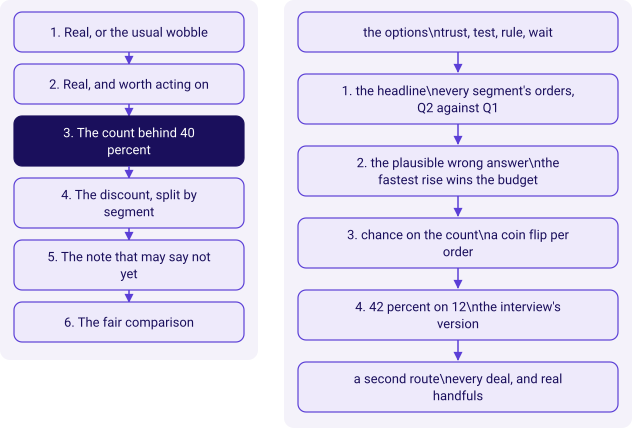

In [2]:
kit.side_by_side(
    kit.ladder(['Real, or the usual wobble', 'Real, and worth acting on', 'The count behind 40 percent', 'The discount, split by segment', 'The note that may say not yet', 'The fair comparison'], lit=2, show=False),
    kit.vflow(['the options\\ntrust, test, rule, wait', "1. the headline\\nevery segment's orders, Q2 against Q1", '2. the plausible wrong answer\\nthe fastest rise wins the budget', '3. chance on the count\\na coin flip per order', "4. 42 percent on 12\\nthe interview's version", 'a second route\\nevery deal, and real handfuls'], show=False),
)

## The options

Four ways a team could answer "should budget follow the 40 percent?". What separates them is what
each needs to know first and what it assumes; the count itself is yours to find in section 2, so
the option that depends on it is sized after that.

| Option | What it does | What it risks |
|---|---|---|
| A. Trust the headline | Rank segments by growth and fund the fastest | Moving money on a rate a coin could make |
| B. A chance reference for the count | Deal each order to a quarter by coin flip and see how often chance makes a 40 percent rise | Nothing, once the count is found |
| C. The rule of thumb | Treat any rate standing on fewer than thirty customers as a lead, however many orders they placed | A blunt line: it says careful and stops there |
| D. Wait for thirty customers | Hold the decision until thirty or more customers stand behind the rate | Time, which depends on how fast new customers arrive |

Option,What it needs,What it assumes,What it risks
A. Trust the headline,4 segments x 2 quarters,the rate is the rise,budget follows a rise a coin could make
B. Coin flips on the count,"the count behind the rate, found in section 2",each order was as likely to land in either quarter,"none, once the count is known"
C. The rule of thumb,"the customers behind the rate, against thirty",thirty independent buyers is roughly where a rate settles,it says careful and stops there
D. Wait for thirty customers,"the customers behind the rate and how fast new ones arrive, sized after section 2",new customers keep arriving,the chance to invest early


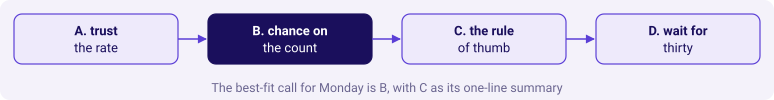

In [3]:
order_segments = ["Retail-Core", "Retail-Plus", "Business", "Student"]
rows = [
    ("A. Trust the headline", f"{len(order_segments)} segments x 2 quarters", "the rate is the rise",
     "budget follows a rise a coin could make"),
    ("B. Coin flips on the count", "the count behind the rate, found in section 2",
     "each order was as likely to land in either quarter", "none, once the count is known"),
    ("C. The rule of thumb", "the customers behind the rate, against thirty",
     "thirty independent buyers is roughly where a rate settles", "it says careful and stops there"),
    ("D. Wait for thirty customers", "the customers behind the rate and how fast new ones arrive, sized after section 2",
     "new customers keep arriving", "the chance to invest early"),
]
kit.table(["Option", "What it needs", "What it assumes", "What it risks"], rows,
          caption="The options sized by what each needs and assumes")
kit.flow(["A. trust\nthe rate", "B. chance on\nthe count", "C. the rule\nof thumb", "D. wait for\nthirty"], lit=1,
         title="The best-fit call for Monday is B, with C as its one-line summary")
kit.check("every segment carries orders in both quarters, so every rate exists",
          all(orders_in(s, "Q1") > 0 and orders_in(s, "Q2") > 0 for s in order_segments))

**The best-fit call: B, said with C.** The coin flips tell Meera how often chance alone makes her
headline, which is the question; the rule of thumb is the sentence she remembers. The rule counts
customers, because more orders from the same few customers add orders and no new evidence: thirty
orders from two people are still two people's habits. D is the action the answer may lead to, and
how long it takes depends on how many customers stand behind the rate, so you size it once you have
found them. **The fact that would change the call.** A cheap way to buy more orders fast, such
as a small paid test aimed only at students: then D stops being a wait and becomes a two-week
experiment.

## 1. The headline: every segment's orders, Q2 against Q1

Meera's 40 percent is about orders placed, whatever their status. Put every segment on the same
footing: Q2 orders for every 100 orders in Q1.

**Predict before you run.** Which segment shows the biggest rise? a) Business, since it carries the
revenue; b) Retail-Core; c) Student; d) none rose.

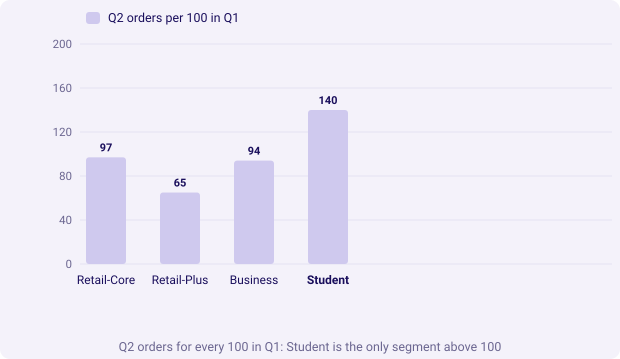

Retail-Core  -3 percent
Retail-Plus  -35 percent
Business     -6 percent
Student      +40 percent


In [4]:
index = {s: round(100 * orders_in(s, "Q2") / orders_in(s, "Q1")) for s in order_segments}
kit.columns(order_segments, [("Q2 orders per 100 in Q1", [index[s] for s in order_segments])], lit=[3], width=620,
            title="Q2 orders for every 100 in Q1: Student is the only segment above 100")
for s in order_segments:
    print(f"{s:12s} {index[s] - 100:+d} percent")
kit.check("Student's orders rose 40 percent", index["Student"] == 140, f"{index['Student']}")
kit.check("Student is the only segment above 100", [s for s in order_segments if index[s] > 100] == ["Student"])

**What happened.** The answer is c. Student is the only segment whose orders rose, by 40 percent,
while Retail-Plus fell 35 and the other two slipped a few points. Read as a leaderboard, Student
wins.

## 2. The plausible wrong answer

**The plausible wrong answer.** The draft reads the leaderboard as a plan.

In [5]:
fastest = max(order_segments, key=lambda s: index[s])
draft = f"{fastest} is up {index[fastest] - 100} percent, the fastest on the page: move acquisition budget to {fastest}."
print(draft)

Student is up 40 percent, the fastest on the page: move acquisition budget to Student.


**Why it is wrong.** The rate is correct arithmetic and it travels without its count. A rise of 40
percent on four hundred orders and on a handful of orders are different facts: on a handful, one or
two orders landing in one quarter rather than the other makes the whole rise, and the budget would
follow them.

**Your turn: the check.** Type these lines into the empty cell below and run them. Then write, in
one sentence, how many orders and how many customers stand behind Meera's 40 percent:

```python
student = [o for o in ORDERS if o["segment"] == "Student"]
print(len(student), "Student orders across both quarters")
print({q: sum(1 for o in student if o["quarter"] == q) for q in ("Q1", "Q2")})
print(len({o["customer_id"] for o in student}), "distinct Student customers")
```

**Your turn, continued: size option D.** Option D waits until thirty or more customers stand
behind the rate, since more orders from the same customers settle nothing. How fast are new Student
customers arriving? Type these lines into the next empty cell:

```python
q1_buyers = {o["customer_id"] for o in student if o["quarter"] == "Q1"}
q2_buyers = {o["customer_id"] for o in student if o["quarter"] == "Q2"}
print(len(q1_buyers | q2_buyers), "customers behind the rise;", len(q2_buyers - q1_buyers), "of them new in Q2")
```

Then write one sentence on how long waiting for thirty customers would take at that pace, and one on
what a two-week paid test aimed at new students would change.

The mechanism, on **invented** segments: how many points one extra order moves a rate, at four
sizes.

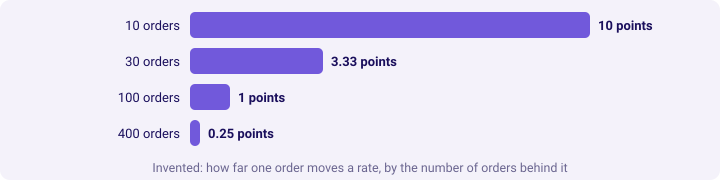

In [6]:
sizes = [10, 30, 100, 400]
kit.bars([(f"{n} orders", round(100 / n, 2)) for n in sizes], fmt=lambda v: f"{v:g} points",
         title="Invented: how far one order moves a rate, by the number of orders behind it")
kit.check("on ten orders, one order is ten points", 100 / sizes[0] == 10)

## 3. Chance on the count: a coin flip per order

Chapter 1's flips swapped each member's two quarters. For a count, the chance reference is simpler
still: if Student's ordering had not changed, each Student order was as likely to land in Q1 as in
Q2. Flip a coin per order, 5,000 times, and count how often chance alone makes a rise of 40 percent
or more.

**Predict before you run.** For Student's own orders, what share of coin-flip worlds show a rise of
40 percent or more? a) under 1 percent; b) about 5 percent; c) about 40 percent; d) all of them.

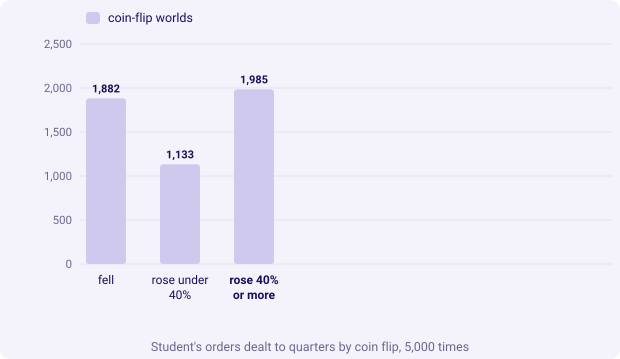

share of chance-only worlds with a rise of 40 percent or more: 0.397


In [7]:
student_orders = sum(1 for o in ORDERS if o["segment"] == "Student")
flips = flip_rises(student_orders, 5000, seed=2026)


def bucket(rises):
    """Three plain buckets, so the chart says what the decision needs and nothing else."""
    return [sum(1 for r in rises if r < 0), sum(1 for r in rises if 0 <= r < 0.4 - 1e-9),
            sum(1 for r in rises if r >= 0.4 - 1e-9)]


student_share = sum(1 for r in flips if r >= 0.4 - 1e-9) / len(flips)
kit.columns(["fell", "rose under 40%", "rose 40% or more"], [("coin-flip worlds", bucket(flips))],
            lit=[2], width=620, title="Student's orders dealt to quarters by coin flip, 5,000 times")
print(f"share of chance-only worlds with a rise of 40 percent or more: {student_share:.3f}")

**What happened.** The answer is c. About four in ten coin-flip worlds make a rise of 40 percent or
more from Student's orders alone. Chance makes Meera's headline almost as often as not, and the flips
are generous: they treat each order as its own draw, while Student's orders come from very few
customers, whose orders move together. Now the same 40 percent on bigger counts: a segment with
Retail-Core's orders, and an **invented** segment of 400.

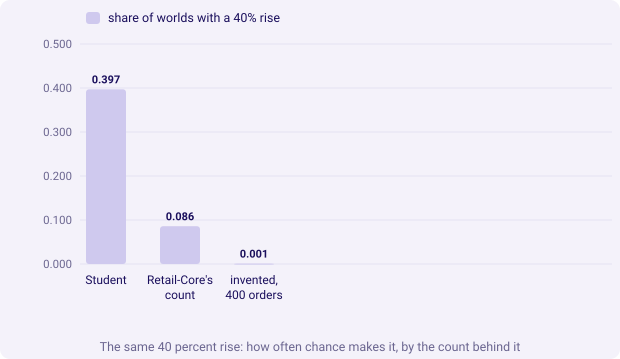

In [8]:
core_n = sum(1 for o in ORDERS if o["segment"] == "Retail-Core")
compare = {"Student": student_share}
core_label = "Retail-Core's count"
for label, n in [(core_label, core_n), ("invented, 400 orders", 400)]:
    rises = flip_rises(n, 5000, seed=2026)
    compare[label] = sum(1 for r in rises if r >= 0.4 - 1e-9) / len(rises)
kit.columns(list(compare), [("share of worlds with a 40% rise", [round(v, 3) for v in compare.values()])],
            fmt=lambda v: f"{v:.3f}", width=620, title="The same 40 percent rise: how often chance makes it, by the count behind it")
kit.check("chance makes Student's rise in more than a third of worlds", student_share > 0.33, f"{student_share:.3f}")
kit.check("on Retail-Core's count the same rise is rare", compare[core_label] < 0.10, f"{compare[core_label]:.3f}")
kit.check("on 400 orders chance almost never makes it", compare["invented, 400 orders"] < 0.002)

**The fix.** The rate, its count, and whether chance makes it, with the decision that follows:
"Student orders rose 40 percent, on a count so small that chance alone makes a rise that size in
about 40 percent of coin-flip worlds. Not yet: we watch Student until more customers buy, thirty or
more behind the rise, before any budget moves." What changed: the decision. The draft moved budget;
the fix moves nothing and names the count that would reopen the question, in customers, since
orders from the same few customers are one habit counted again.

## 4. 42 percent on 12 users, or 31 percent on 1,200?

The interview's version of Student, **invented** with the interview's numbers. Suppose the true
rate for everyone were 31 percent. How often would a group of only 12 users show 42 percent or more,
by chance alone?

**Predict before you run.** a) almost never; b) about 1 time in 20; c) about 1 time in 3; d) always.

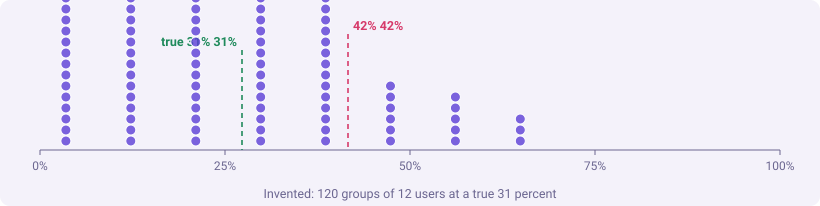

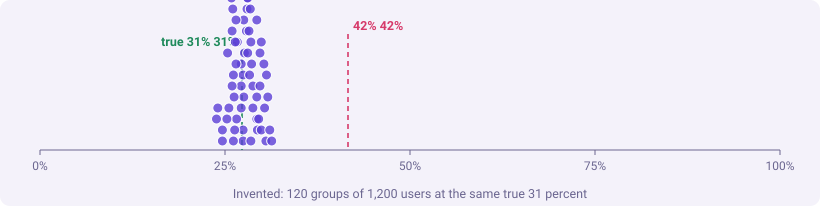

groups of 12 at 42% or more: 30.9%; groups of 1,200: 27.7% to 34.8%


In [9]:
random.seed(2026)
small_rates = [sum(1 for _ in range(12) if random.random() < 0.31) / 12 for _ in range(5000)]
large_rates = [sum(1 for _ in range(1200) if random.random() < 0.31) / 1200 for _ in range(300)]
small_share = sum(1 for r in small_rates if r >= 5 / 12 - 1e-9) / len(small_rates)
kit.strip(small_rates[:120], markers=[("42%", 5 / 12, "bad"), ("true 31%", 0.31, "good")], lo=0, hi=1,
          fmt=lambda v: f"{v:.0%}", title="Invented: 120 groups of 12 users at a true 31 percent")
kit.strip(large_rates[:120], markers=[("42%", 5 / 12, "bad"), ("true 31%", 0.31, "good")], lo=0, hi=1,
          fmt=lambda v: f"{v:.0%}", title="Invented: 120 groups of 1,200 users at the same true 31 percent")
print(f"groups of 12 at 42% or more: {small_share:.1%}; groups of 1,200: {min(large_rates):.1%} to {max(large_rates):.1%}")
kit.check("a true 31 percent reads 42 or more on 12 users about a third of the time", 0.25 < small_share < 0.37,
          f"{small_share:.3f}")
kit.check("on 1,200 users it never reaches 42 percent", max(large_rates) < 5 / 12, f"{max(large_rates):.3f}")

**What happened.** The answer is c. A true 31 percent shows up as 42 percent or more in about 31
percent of groups of twelve, while groups of 1,200 all land between about 28 and 35 percent. One
user out of twelve is 8.3 points; one out of 1,200 is under a tenth of a point.

## A second route: every deal counted, and real handfuls

The coin flips sampled 5,000 worlds. Two checks follow. The first recounts the same coin model
exactly: with a count this small, every possible way of dealing the orders to the two quarters can
be listed. The second checks the idea rather than the arithmetic, on real orders: Retail-Core's
orders fell 3 percent between the quarters, so draw handfuls of them the size of Student's count
and see how often a handful shows a 40 percent rise anyway.

**Predict before you run.** How often will a Student-sized handful of Retail-Core's real orders show
a rise of 40 percent or more? a) never, since Retail-Core fell; b) about 1 time in 20; c) about 1
time in 3; d) about 9 times in 10.

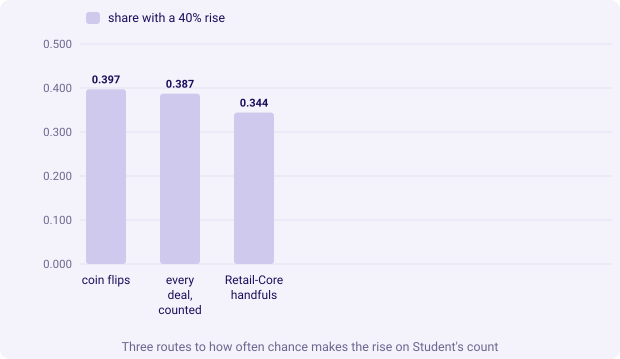

exact share 0.387; the flips said 0.397; Student-sized handfuls of Retail-Core's orders 0.344; handfuls of sixty 0.0004


In [10]:
deals = list(itertools.product(["Q1", "Q2"], repeat=student_orders))
rising = 0
for deal in deals:
    q2 = deal.count("Q2")
    q1 = student_orders - q2
    if q1 == 0 or q2 / q1 - 1 >= 0.4 - 1e-9:
        rising += 1
exact_share = rising / len(deals)

core_orders = [o for o in ORDERS if o["segment"] == "Retail-Core"]


def handful_share(size, times=5000, seed=2026):
    """Draw handfuls of Retail-Core's real orders and count how often a handful shows a 40 percent rise."""
    random.seed(seed)
    hits = 0
    for _ in range(times):
        hand = random.sample(core_orders, size)
        q1 = sum(1 for o in hand if o["quarter"] == "Q1")
        if q1 == 0 or (size - q1) / q1 - 1 >= 0.4 - 1e-9:
            hits += 1
    return hits / times


handfuls = handful_share(student_orders)
bigger = handful_share(60)
kit.columns(["coin flips", "every deal, counted", "Retail-Core handfuls"],
            [("share with a 40% rise", [round(student_share, 3), round(exact_share, 3), round(handfuls, 3)])],
            fmt=lambda v: f"{v:.3f}", width=620, title="Three routes to how often chance makes the rise on Student's count")
print(f"exact share {exact_share:.3f}; the flips said {student_share:.3f}; Student-sized handfuls of Retail-Core's orders "
      f"{handfuls:.3f}; handfuls of sixty {bigger:.4f}")
kit.check("the exact count and the flips agree within two points", abs(exact_share - student_share) < 0.02,
          f"{exact_share:.3f} against {student_share:.3f}")
kit.check("real handfuls from a segment that fell show the rise about a third of the time", 0.25 < handfuls < 0.45,
          f"{handfuls:.3f}")
kit.check("handfuls of sixty almost never show it", bigger < 0.01, f"{bigger:.4f}")

**What happened.** The answer is c. Counting every deal gives 0.387 where the flips gave 0.397, so
the flips were computed right. The handfuls check the idea: Retail-Core's orders fell 3 percent, yet
a handful of them the size of Student's count shows a 40 percent rise about a third of the time
(0.344), and a handful of sixty almost never does. The swing belongs to small counts, whatever
segment they come from, so the verdict holds: chance makes Meera's headline about four times in
ten. **When to switch.** Count every deal while the count is small enough to list; on a few dozen
orders the list runs into the billions, and the flips are the only practical route.

> **Kavya's review.** "Student's rise is real arithmetic on too few orders, from too few customers,
> to act on. Count both, say how often chance makes the rise, and give Meera the number of customers
> that would reopen it. That is a complete answer, and it costs nothing to be right later."

### In the interview

**[F] 42 percent on 12 users against 31 percent on 1,200; which do you trust?** "The 31 percent, as
the working estimate. On 12 users one person moves the rate by more than 8 points, so 42 percent is
well inside what chance produces around a true rate near 31. I keep the 42 as a lead: find out what
is different about that group and measure it on more users before acting."

**[D] A segment is up 40 percent and the CEO wants to move budget; you can trust it, test it on the
count, or wait. Which, and what would change your mind?** "Test it on the count first: how often do
coin flips make that rise on that many orders, and how many customers placed them? If chance makes it
often, or a few customers made it, the answer is not yet, with the number of customers that would
reopen it. A cheap, fast way to reach new customers in that segment would turn the wait into a short
experiment, and I would propose that."

### Depth: where thirty comes from

Thirty is a habit, and no law: it is roughly where a count of independent observations stops
swinging wildly from one extra. Orders from the same customer are not independent, since a customer
who orders once tends to order again, so the observations that count are customers: thirty orders
from two customers are two observations. The curve below is the coin-flip chance of a 40 percent
rise at growing counts of independent buyers, each buying once, the same simulation as section 3.

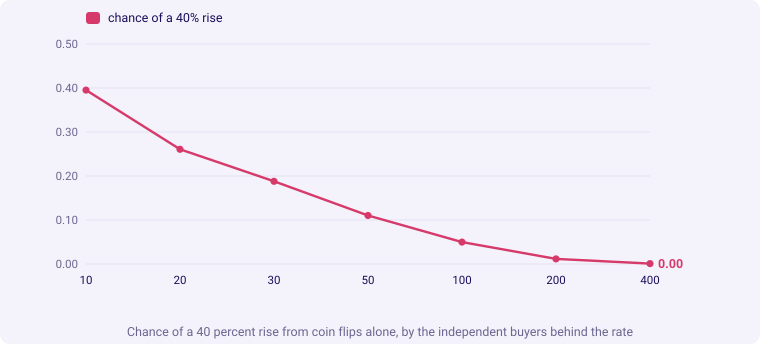

In [11]:
counts = [10, 20, 30, 50, 100, 200, 400]
curve = []
for n in counts:
    rises = flip_rises(n, 3000, seed=2026)
    curve.append(sum(1 for r in rises if r >= 0.4 - 1e-9) / len(rises))
kit.line([str(n) for n in counts], [("chance of a 40% rise", curve, "bad")], fmt=lambda v: f"{v:.2f}",
         title="Chance of a 40 percent rise from coin flips alone, by the independent buyers behind the rate")
kit.check("the chance falls below one in five by thirty independent buyers", curve[2] < 0.2, f"{curve[2]:.3f}")

In [12]:
kit.check_summary()
print("Next: chapter 4. Marketing says the monsoon sale lifted revenue 6 percent; split it by segment.")

Next: chapter 4. Marketing says the monsoon sale lifted revenue 6 percent; split it by segment.
